In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# 1. CARGA E INGENIERÍA DE DATOS

df_train = pd.read_csv("TrainMWB.csv")
df_test = pd.read_csv("TestMWB.csv")

def crear_caracteristicas_ingenieria(df):
    df_out = df.copy()

    # 1. MALESTAR PSICOLÓGICO
    df_out["Mental_Distress_Score"] = (
        df_out["Anxiety_Score"] +
        df_out["Depression_Score"] +
        df_out["Loneliness_Score"]
    ) / 3

    # 2. PRESIÓN SOCIAL
    df_out["Social_Pressure_Score"] = (
        df_out["FOMO_Score"] +
        df_out["Social_Comparison_Score"] +
        df_out["Validation_Seeking_Score"]
    ) / 3

    # 3. PANTALLA/SUEÑO
    df_out["Screen_Sleep_Ratio"] = df_out["Daily_Usage_Hours"] / (df_out["Sleep_Hours"])

    # 4. BALANCE VIDA-PANTALLA
    df_out["Life_Balance_Score"] = (
        df_out["Offline_Relationship_Quality"] +
        df_out["Physical_Activity_Hrs_Week"] +
        df_out["Screen_Free_Time_Hrs"]
    ) / 3

    # 5. COMPULSIVE_USAGE_RATIO
    df_out["Compulsive_Usage_Ratio"] = df_out["Scroll_Without_Purpose"] / df_out["Daily_Usage_Hours"]

    # 6. NOTIFICATION_EFFICIENCY
    df_out["Notification_Efficiency"] = df_out["Notifications_Per_Day"] / df_out["Daily_Usage_Hours"]

    # 7. SELF_ESTEEM_VS_VALIDATION: gap entre autoestima y búsqueda de validación
    df_out["Self_Esteem_vs_Validation"] = df_out["Self_Esteem_Score"] - df_out["Validation_Seeking_Score"]

    # 8. SOCIAL_ISOLATION_INDEX: soledad vs relaciones offline
    df_out["Social_Isolation_Index"] = df_out["Loneliness_Score"] - df_out["Offline_Relationship_Quality"]

    return df_out

df_train = crear_caracteristicas_ingenieria(df_train)
df_test = crear_caracteristicas_ingenieria(df_test)

nuevas_columnas = ["Mental_Distress_Score", "Social_Pressure_Score", "Social_Isolation_Index", "Notification_Efficiency", "Screen_Sleep_Ratio", "Compulsive_Usage_Ratio","Self_Esteem_vs_Validation", "Life_Balance_Score"]
print(f"Creadas {len(nuevas_columnas)} nuevas características:")
for col in nuevas_columnas:
    print(f"- {col}")



Creadas 8 nuevas características:
- Mental_Distress_Score
- Social_Pressure_Score
- Social_Isolation_Index
- Notification_Efficiency
- Screen_Sleep_Ratio
- Compulsive_Usage_Ratio
- Self_Esteem_vs_Validation
- Life_Balance_Score


In [57]:
# 2. PREPARACIÓN DE DATOS PARA MODELADO

target_col = 'Addiction_Level'
columnas_a_eliminar = ['User_ID', 'Anxiety_Score', 'Depression_Score',
'Loneliness_Score', 'Self_Esteem_Score', 'FOMO_Score', 'Social_Comparison_Score',
'Validation_Seeking_Score', 'Productivity_Loss_Score','Sleep_Quality_Score']

X_train = df_train.drop(columns=columnas_a_eliminar + [target_col])
y_train = df_train[target_col]

X_test = df_test.drop(columns=columnas_a_eliminar + [target_col])
y_test = df_test[target_col]

print(f"Variables de entrada: {X_train.shape[1]}")
print(f"Target variable: {target_col}")

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

Variables de entrada: 27
Target variable: Addiction_Level


In [58]:
# 3. CONSTRUCCIÓN DEL PIPELINE
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
], verbose=1)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(score_func=f_classif)),
    ('knn', KNeighborsClassifier())
])

In [59]:
# 4. FUNCIÓN DE ENTRENAMIENTO Y EVALUACIÓN

def entrenar_y_evaluar(X_train, X_test, y_train, y_test, param_grid, nombre_modelo, verbose=True):
    if verbose:
        print(f"Entrenando {nombre_modelo}")

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=46)

    grid = GridSearchCV(
        pipeline,
        param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)

    cv_f1 = grid.best_score_
    test_f1 = f1_score(y_test, y_pred, average='macro')
    test_acc = accuracy_score(y_test, y_pred)

    resultados = {
        'Modelo': nombre_modelo,
        'K Features': grid.best_params_['selector__k'],
        'N Vecinos': grid.best_params_['knn__n_neighbors'],
        'Métrica': grid.best_params_['knn__metric'],
        'CV F1': round(cv_f1, 3),
        'Test F1': round(test_f1, 3),
        'Test Accuracy': round(test_acc, 3)
    }

    if verbose:
        print(f"CV F1: {cv_f1:.3f} | Test F1: {test_f1:.3f} | Test Acc: {test_acc:.3f}")

    return resultados, grid, y_pred

In [60]:
# 5. EXPERIMENTO A: MODELO BASE (Todas las variables sin filtrado)

print("EXPERIMENTO A: MODELO BASE")
param_grid_base = {
    'selector__k': ['all'],
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__metric': ['manhattan', 'euclidean']
}

resultado_base, grid_base, pred_base = entrenar_y_evaluar(
    X_train, X_test, y_train, y_test,
    param_grid_base,
    "Modelo Base",
    verbose=True
)

EXPERIMENTO A: MODELO BASE
Entrenando Modelo Base
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[ColumnTransformer] ........... (1 of 2) Processing num, total=   0.0s
[ColumnTransformer] ........... (2 of 2) Processing cat, total=   0.0s
CV F1: 0.574 | Test F1: 0.582 | Test Acc: 0.586


In [52]:
# 6. EXPERIMENTO B: MODELO OPTIMIZADO (Selección dinámica)

print("EXPERIMENTO B: MODELO OPTIMIZADO")
param_grid_optimized = {
    'selector__k': [10, 12, 15, 18, 20, 23, 25],
    'knn__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
    'knn__metric': ['manhattan', 'euclidean']
}

resultado_opt, grid_opt, pred_opt = entrenar_y_evaluar(
    X_train, X_test, y_train, y_test,
    param_grid_optimized,
    "Modelo Optimizado",
    verbose=True
)


EXPERIMENTO B: MODELO OPTIMIZADO
Entrenando Modelo Optimizado
Fitting 5 folds for each of 140 candidates, totalling 700 fits
[ColumnTransformer] ........... (1 of 2) Processing num, total=   0.0s
[ColumnTransformer] ........... (2 of 2) Processing cat, total=   0.0s
CV F1: 0.674 | Test F1: 0.709 | Test Acc: 0.713


In [53]:
# 7. TABLA COMPARATIVA Y ANÁLISIS

print("COMPARATIVA DE MODELOS")

df_resultados = pd.DataFrame([resultado_base, resultado_opt])
print(df_resultados.to_string(index=False))

mejora_f1 = ((resultado_opt['Test F1'] - resultado_base['Test F1']) / resultado_base['Test F1'] * 100)
mejora_acc = ((resultado_opt['Test Accuracy'] - resultado_base['Test Accuracy']) / resultado_base['Test Accuracy'] * 100)

print(f"Mejora con optimización:")
print(f" F1: {resultado_base['Test F1']:.3f} -> {resultado_opt['Test F1']:.3f} ({mejora_f1:+.1f}%)")
print(f" Accuracy: {resultado_base['Test Accuracy']:.3f} -> {resultado_opt['Test Accuracy']:.3f} ({mejora_acc:+.1f}%)")

COMPARATIVA DE MODELOS
           Modelo K Features  N Vecinos   Métrica  CV F1  Test F1  Test Accuracy
      Modelo Base        all         15 manhattan  0.574    0.582          0.586
Modelo Optimizado         10         21 manhattan  0.674    0.709          0.713
Mejora con optimización:
 F1: 0.582 -> 0.709 (+21.8%)
 Accuracy: 0.586 -> 0.713 (+21.7%)


In [54]:
# 8. DETALLE DEL MODELO OPTIMIZADO

print("ANÁLISIS DEL MODELO OPTIMIZADO")

feature_names = grid_opt.best_estimator_['preprocessor'].get_feature_names_out()
mask = grid_opt.best_estimator_['selector'].get_support()
selected_features = feature_names[mask]

print(f"Top {len(selected_features)} features seleccionadas:")
for i, feature in enumerate(selected_features, 1):
    print(f"   {i}. {feature}")

print("Matriz de confusión (Test):")
cm = confusion_matrix(y_test, pred_opt)
print(cm)

print("Reporte de clasificación:")
clases_ordenadas = np.unique(y_test)
print(classification_report(y_test, pred_opt, target_names=[str(c) for c in clases_ordenadas]))

ANÁLISIS DEL MODELO OPTIMIZADO
Top 10 features seleccionadas:
   1. num__Daily_Usage_Hours
   2. num__Scroll_Without_Purpose
   3. num__Mental_Wellbeing_Score
   4. num__Social_Pressure_Score
   5. num__Screen_Sleep_Ratio
   6. num__Life_Balance_Score
   7. num__Self_Esteem_vs_Validation
   8. num__Social_Isolation_Index
   9. cat__First_Check_Morning_AFTER 30 MIN
   10. cat__First_Check_Morning_WITHIN 5 MIN
Matriz de confusión (Test):
[[51  0  9  6]
 [ 0 69 16  0]
 [22 16 78  0]
 [22  0  1 31]]
Reporte de clasificación:
              precision    recall  f1-score   support

        HIGH       0.54      0.77      0.63        66
         LOW       0.81      0.81      0.81        85
    MODERATE       0.75      0.67      0.71       116
      SEVERE       0.84      0.57      0.68        54

    accuracy                           0.71       321
   macro avg       0.73      0.71      0.71       321
weighted avg       0.74      0.71      0.72       321



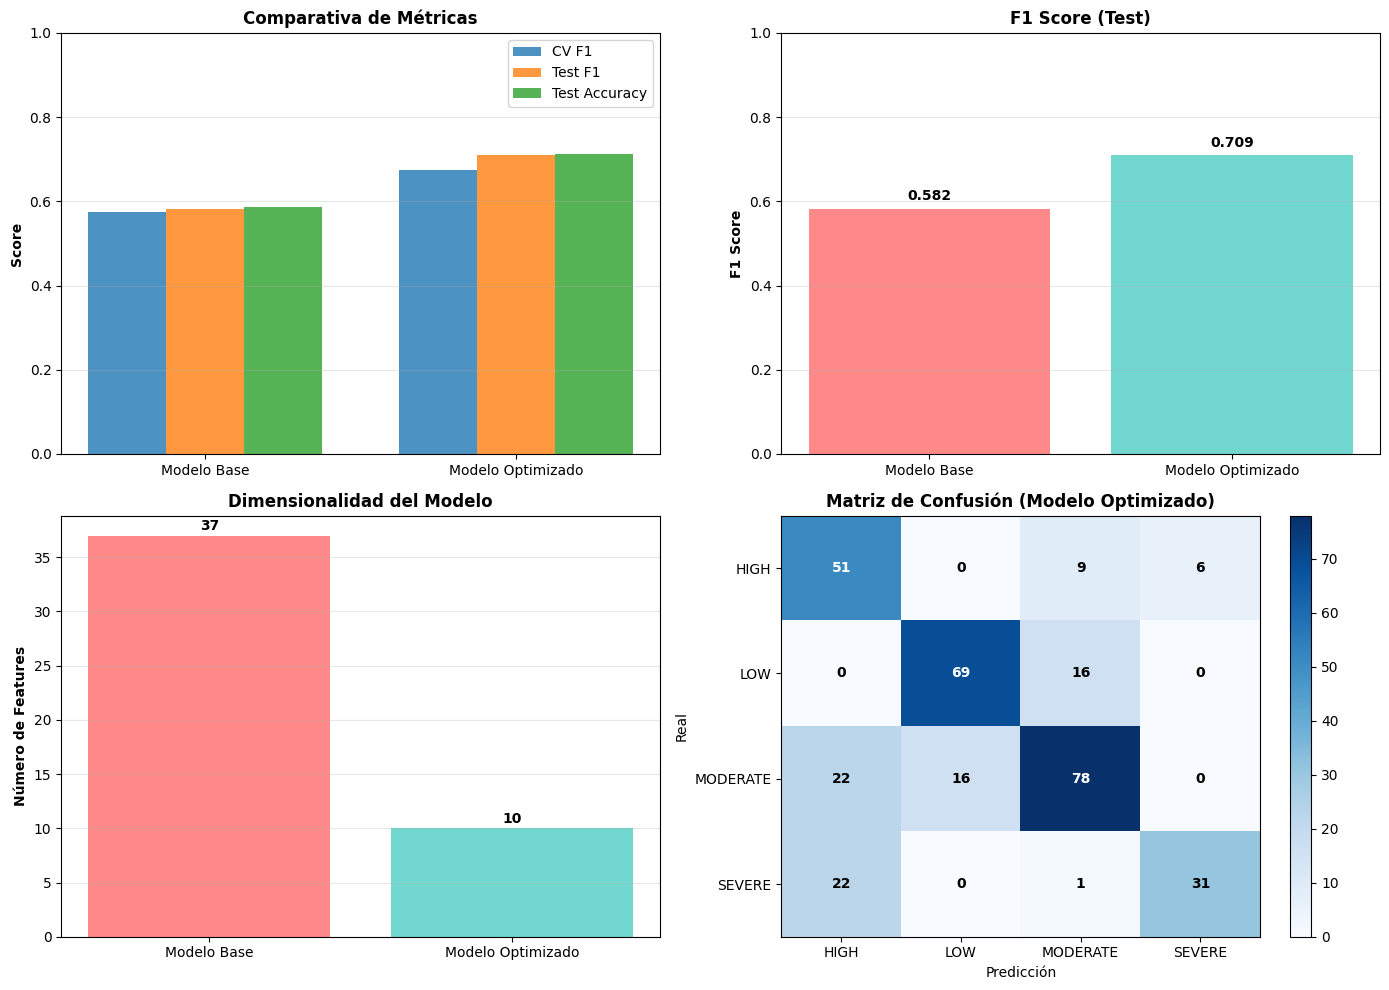

In [55]:
# 9. VISUALIZACIONES
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Comparativa de métricas
ax1 = axes[0, 0]
modelos = df_resultados['Modelo'].tolist()
x = np.arange(len(modelos))
width = 0.25

for i, metric in enumerate(['CV F1', 'Test F1', 'Test Accuracy']):
    ax1.bar(x + i*width, df_resultados[metric], width, label=metric, alpha=0.8)

ax1.set_ylabel('Score', fontweight='bold')
ax1.set_title('Comparativa de Métricas', fontweight='bold')
ax1.set_xticks(x + width)
ax1.set_xticklabels(modelos)
ax1.legend()
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)

# 2. F1 Score
ax2 = axes[0, 1]
f1_scores = [resultado_base['Test F1'], resultado_opt['Test F1']]
colors = ['#FF6B6B', '#4ECDC4']
bars = ax2.bar(modelos, f1_scores, color=colors, alpha=0.8)
ax2.set_ylabel('F1 Score', fontweight='bold')
ax2.set_title('F1 Score (Test)', fontweight='bold')
ax2.set_ylim([0, 1])
for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{score:.3f}', ha='center', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Dimensionalidad
ax3 = axes[1, 0]
# Manejar el caso donde K Features sea 'all' para la gráfica
k_base_num = len(feature_names) if resultado_base['K Features'] == 'all' else resultado_base['K Features']
features_count = [k_base_num, resultado_opt['K Features']]
bars = ax3.bar(modelos, features_count, color=colors, alpha=0.8)
ax3.set_ylabel('Número de Features', fontweight='bold')
ax3.set_title('Dimensionalidad del Modelo', fontweight='bold')
for bar, count in zip(bars, features_count):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{int(count)}', ha='center', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Matriz de confusión
ax4 = axes[1, 1]
im = ax4.imshow(cm, cmap='Blues', aspect='auto')
ax4.set_title('Matriz de Confusión (Modelo Optimizado)', fontweight='bold')
ax4.set_xlabel('Predicción')
ax4.set_ylabel('Real')
ax4.set_xticks(range(len(clases_ordenadas)))
ax4.set_yticks(range(len(clases_ordenadas)))
ax4.set_xticklabels(clases_ordenadas)
ax4.set_yticklabels(clases_ordenadas)

for i in range(len(clases_ordenadas)):
    for j in range(len(clases_ordenadas)):
        ax4.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black", fontweight='bold')

plt.colorbar(im, ax=ax4)
plt.tight_layout()
plt.savefig('analisis_modelos.png', dpi=300, bbox_inches='tight')
plt.show()